In [32]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [24]:
# import dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [22]:
# 5 data teratas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
# tipe data & non-null count
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [27]:
# cek missing value per kolom
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
# distribusi siapa yang selamat
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


/tmp/ipykernel_9675/1658364249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


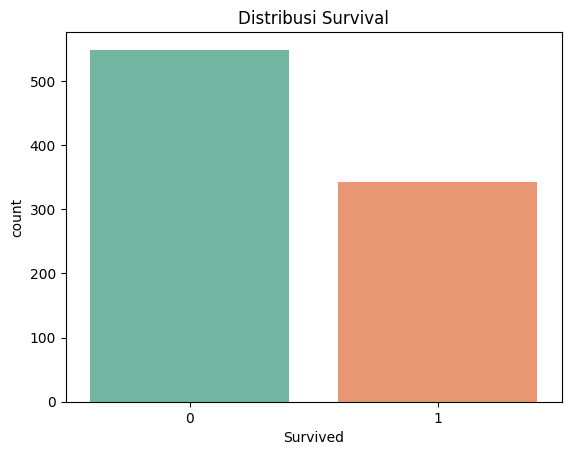

In [29]:
# visualisasi distribusi data survival
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Distribusi Survival')
plt.show()

In [31]:
# Tahap preprocessing data
# 1. Isi missing values Age dengan median
df['Age'].fillna(df['Age'].median(), inplace=True)
# 2. Drop kolom Cabin (terlalu banyak missing) dan kolom yang tidak relevan untuk prediksi
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
# 3. Drop 2 baris yang Embarked-nya NaN
df.dropna(subset=['Embarked'], inplace=True)
# 4. Encode kolom kategorikal → angka. Sex: male=1, female=0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
# Embarked: one-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
print(df.shape)
df.head()

(889, 9)


/tmp/ipykernel_9675/1098924856.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


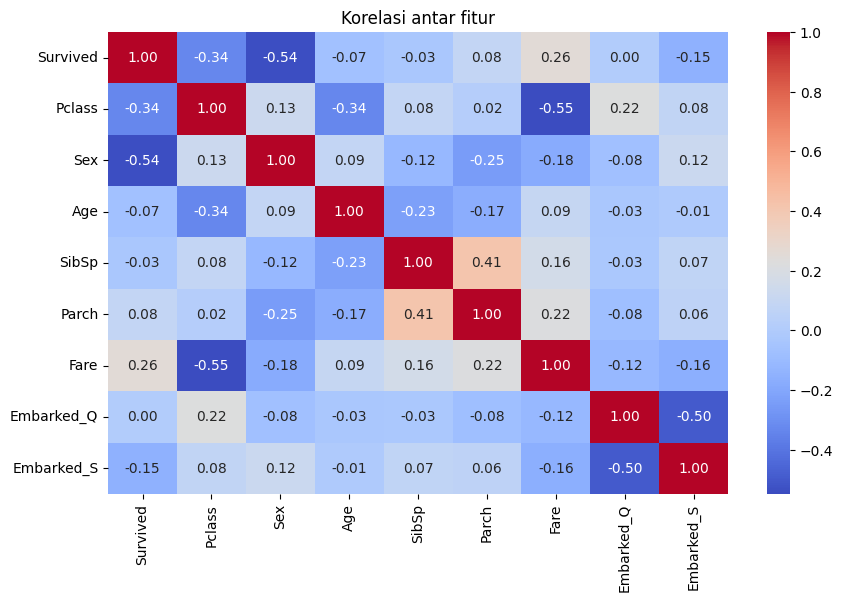

In [33]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi antar fitur')
plt.show()

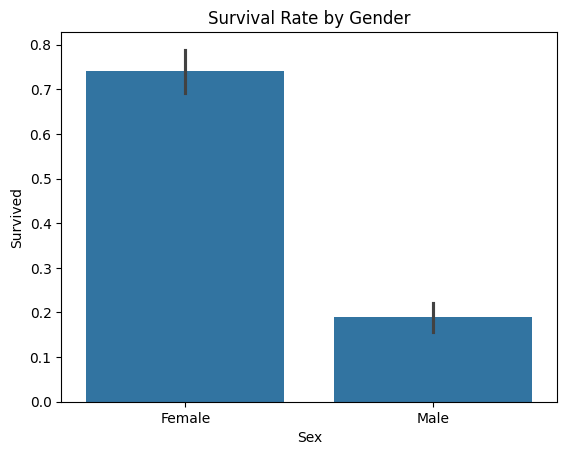

In [34]:
# Survival rate berdasarkan gender
sns.barplot(x='Sex', y='Survived', data=df)
plt.xticks([0,1], ['Female', 'Male'])
plt.title('Survival Rate by Gender')
plt.show()

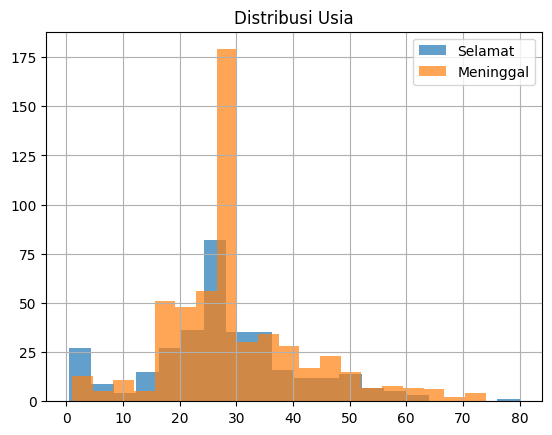

In [36]:
# Distribusi usia per survival group
df[df['Survived']==1]['Age'].hist(alpha=0.7, label='Selamat', bins=20)
df[df['Survived']==0]['Age'].hist(alpha=0.7, label='Meninggal', bins=20)
plt.legend()
plt.title('Distribusi Usia')
plt.show()

In [38]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )
print(f"Training: {len(X_train)} baris")
print(f"Testing: {len(X_test)} baris")
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


Training: 711 baris
Testing: 178 baris


Akurasi: 80.90%
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       109
           1       0.79      0.70      0.74        69

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



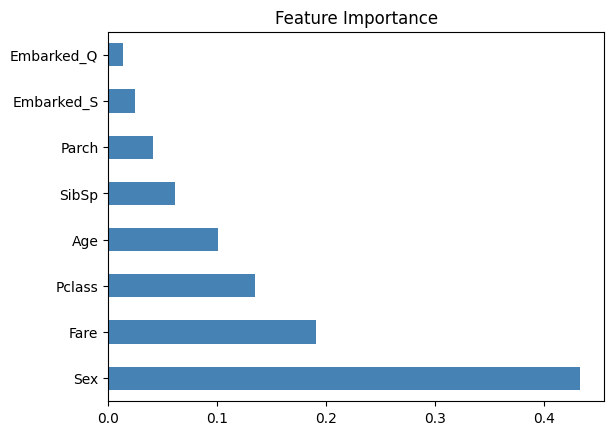

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy:.2%}")
print(classification_report(y_test, y_pred))
importances = pd.Series( model.feature_importances_, index=X.columns ).sort_values(ascending=False)
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.show()